In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
from scipy.stats import t as tdist
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install xgboost
from imblearn.over_sampling import ADASYN












[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Loading the genetic dataset

In [2]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.info
genetic_data.head(10)

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,48,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,49,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,54,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Checking the missing values

In [3]:
genetic_data.isnull().sum()

taglo_id           0
ATLANTIC_124776    0
ESCORT_159228      0
ARGOS_120931       0
ALTURAS_329540     0
                  ..
CARRERA_142554     0
FORTUS_3279866     0
SMART_1883446      0
SALINERO_253609    0
FABULA_171173      0
Length: 95, dtype: int64

In [4]:
# Clean column names
genetic_columns_clean = [c.strip().upper().replace(" ", "").replace(".", "") for c in genetic_data.columns]

# Assign cleaned names back to DataFrame
genetic_data.columns = genetic_columns_clean
print(genetic_data.columns)

Index(['TAGLO_ID', 'ATLANTIC_124776', 'ESCORT_159228', 'ARGOS_120931',
       'ALTURAS_329540', 'ELMUNDO_835520', 'NADINE_241950',
       'VIOLETQUEEN_3345402', 'DEODARA_513721', 'MEMPHIS_2279529',
       'AGRIA_125336', 'PAYETTERUSSET_4617676', 'IVORYRUSSET_1360551',
       'SABABA_4959615', 'CECILE_147140', 'FRISIA_163592', 'CARDYMA_3345873',
       'RICKEYRUSSET_4640884', 'ANIVIA_4446779', 'AVARNA_1630052',
       'DONALD_158741', 'JAERLA_231308', 'ARIZONA_3056017',
       'SARPOMIRA_1629377', 'MARILYN_1632173', 'DESIREE_139717',
       'MUSE_6159099', 'ADORA_123802', 'TAURUS_1883495', 'BERBER_121293',
       'RANGERRUSSET_265488', 'BINTJE_126680', 'FENWAYRED_4055844',
       'KONDOR_248484', 'SAGITTA_1459411', 'CLEARWATERR_2721777',
       'NICOLA_248062', 'TETONRUSSET_3029162', 'FESTIEN_172619',
       'HANSA_180216', 'PEEWEERUSSET_3347291', 'PRINCEOFORANGE_416115',
       'SUPERIOR_1477892', 'VANGOGH_294181', 'CHALLENGER_1883438',
       'JENNIFER_3221728', 'PARELLA_2983716', 'CH

# loading the flavor-aroma dataset which already derived.

In [5]:
merged_flavor_aroma= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_plus_predicted_flavors_94.csv')
merged_flavor_aroma
merged_flavor_aroma.columns

Index(['Variety', '1-Nonanol (Floral, waxy)',
       '2,3-Butanedione (Butter, creamy, sweet)',
       'Benzaldehyde (Almond, cherry, fruity)',
       'Butanal, 3-methyl- (Fruity, malty, chocolate)',
       'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
       'Decanal (Citrus, floral)',
       'Dimethyl trisulfide (Garlic, onion, sulfurous)',
       'Furfural (Sweet, almond, caramel)', 'Hexanal (Green, grassy)',
       'Hexanoic acid (Fatty, cheesy, sweaty)',
       'Methional (Cooked potato, sulfurous)', 'Octanal (Citrus, fruity)',
       'Pentanal (Green, fatty, pungent)', 'Metallic Flavour__pred',
       'Bitter Flavour__pred', 'Earthy Flavour__pred', 'Sour Flavour__pred',
       'Fresh Flavour__pred', 'Sweet Flavour__pred',
       'Root/ Vegetable Flavour__pred', 'Farmyard (grass/hay) flavour__pred',
       'Bitter Aftertaste__pred', 'Sour Aftertaste__pred',
       'Sweet Aftertaste__pred', 'Metallic Flavour__pred_cal',
       'Bitter Flavour__pred_cal', 'Earthy Flavou

# Merge genetic data with aroma_flavor dataset for further analysis

In [6]:
# preparing the data
def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]

# Detecting the SNP marker column 
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

#  Clean genetics 
G = genetic_data.dropna(subset=[mrk_col]) \
                .drop_duplicates(subset=[mrk_col]) \
                .set_index(mrk_col)

G = to_numeric(G)         # convert to numeric (0/1/2)
gd = G.T                  # varieties × markers
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates if multiple rows per variety
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

# copy of  Aroma + Flavor 
af = merged_flavor_aroma.copy()
assert "Variety" in af.columns, "merged_flavor_aroma must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

#proviiding the  Aroma names 
aroma_names = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

col_str = af.columns.astype(str)

# Keeping only the calibrated flavor predictions
flavor_cols = [c for c in col_str if c.endswith("__pred_cal")]

# Keep only whitelist aroma compounds that exist
aroma_cols = [c for c in aroma_names if c in col_str]

# Clean aroma 
A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]   # drop constant cols

# Flavors
F = to_numeric(af[flavor_cols])

print(f"# aroma candidates (usable): {A.shape[1]}")
print(f"# predicted flavor cols (cal only): {F.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

# Merge with genetics
gk = gd.copy()
gk.index.name = "Variety"

merged_all = gk.join(pd.concat([A, F], axis=1), how="inner")
print("Merged shape (varieties × [SNPs + aroma + flavor]):", merged_all.shape)


Genetic table after reshape: (94, 262434)
# aroma candidates (usable): 13
# predicted flavor cols (cal only): 11
Sample aroma cols: ['1-Nonanol (Floral, waxy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)']
Merged shape (varieties × [SNPs + aroma + flavor]): (94, 262458)


In [7]:
# Prepare aroma matrix and PCs from genotype 
OUTDIR = Path("prep_outputs"); OUTDIR.mkdir(parents=True, exist_ok=True)

df = merged_all.copy()
df.index.name = "Variety"

# Aroma intensity columns present
aroma_cols = [c for c in aroma_names if c in df.columns]
if not aroma_cols:
    raise RuntimeError("No aroma columns from AROMA_NAMES found in merged_all.")
print(f"[ok] Found {len(aroma_cols)} aroma columns.")

# Log1p transform for modeling/ANOVA
for c in aroma_cols:
    df[c + "__log1p"] = np.log1p(df[c].astype(float).clip(lower=0))

# SNP columns
SNP_PREFIX = "GEN__" 
snp_cols = [c for c in df.columns if c.startswith(SNP_PREFIX)]
print(f"[info] SNP columns: {len(snp_cols)}")

    # choose up to MAX_SNP_PCA SNPs with least missingness & higher variance
MAX_SNP_PCA = 5000
miss = df[snp_cols].isna().mean(0)                    # missing rate per SNP
var  = df[snp_cols].var(0, skipna=True)               # variance (NaN-safe)
score = (1.0 - miss).rank(ascending=False) + var.rank(ascending=False)
pick = score.sort_values(ascending=False).index[:min(MAX_SNP_PCA, len(snp_cols))]

    # impute mode genotype (most_frequent), cast to float32 to save memory
G = df[pick].astype('float32')
imputer = SimpleImputer(strategy="most_frequent")
G_imp = imputer.fit_transform(G)   # shape: (n_samples, p)

# IncrementalPCA 
ipca = IncrementalPCA(n_components=5, batch_size=512)
PCs = ipca.fit_transform(G_imp)
evr = getattr(ipca, "explained_variance_ratio_", None)

 
for i in range(5):
    df[f"PC{i+1}"] = PCs[:, i]

if evr is not None:
    cum = evr.cumsum()
    print(f"[ok] Added PCs: PC1–PC5 | EVR={np.round(evr,3)} | cumulative={np.round(cum,3)}")
else:
    print("[ok] Added PCs: PC1–PC5")

# Stash prepared DF
df.to_csv("C:/Users/fatemehm/OneDrive - Royal HZPC Group\Desktop/internship/bio_rep1/merged_prepared.csv")



<>:50: SyntaxWarning: invalid escape sequence '\D'
<>:50: SyntaxWarning: invalid escape sequence '\D'
C:\Users\fatemehm\AppData\Local\Temp\ipykernel_7716\745414124.py:50: SyntaxWarning: invalid escape sequence '\D'
  df.to_csv("C:/Users/fatemehm/OneDrive - Royal HZPC Group\Desktop/internship/bio_rep1/merged_prepared.csv")


[ok] Found 13 aroma columns.
[info] SNP columns: 262434
[ok] Added PCs: PC1–PC5 | EVR=[0.457 0.254 0.084 0.049 0.014] | cumulative=[0.457 0.711 0.795 0.844 0.859]


# HCA (Ward, Euclidean) on aroma profiles (EDA)

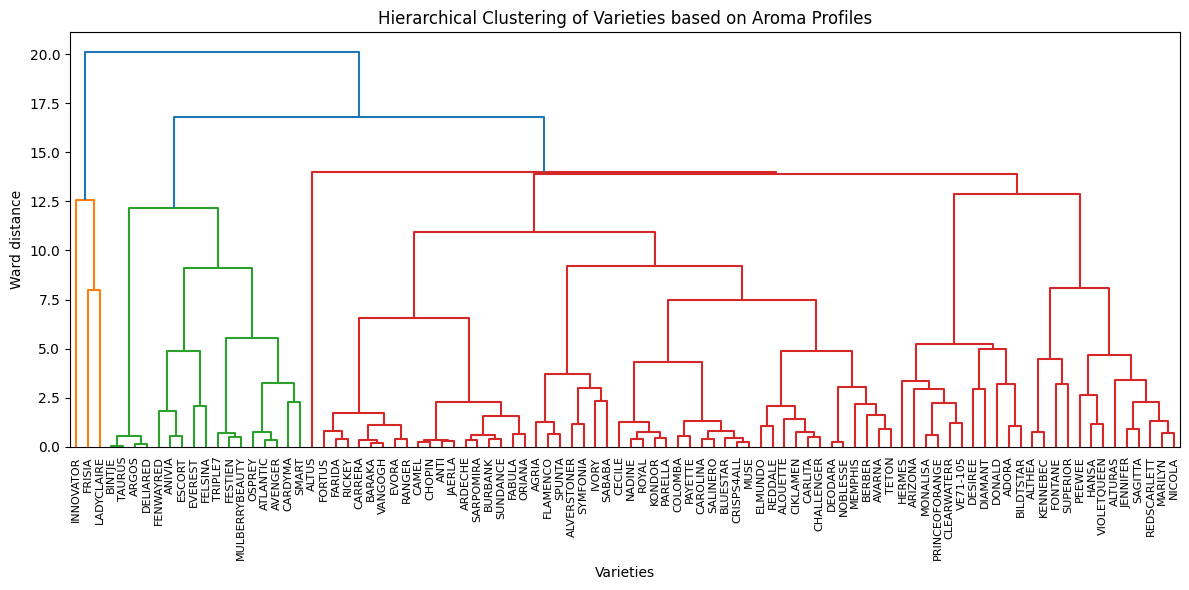

In [8]:

merged_prepared = df.copy()

# use the same aroma list
AROMA_COLS = [c for c in aroma_names if c in merged_prepared.columns]
assert AROMA_COLS, "No aroma columns found in merged_prepared.csv."

X = merged_prepared[AROMA_COLS].copy().fillna(0.0)

# scale columns so compounds contribute equally
Xz = pd.DataFrame(StandardScaler().fit_transform(X.values),
                  index=X.index, columns=AROMA_COLS)

Z = linkage(Xz, method="ward", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Varieties based on Aroma Profiles")
plt.xlabel("Varieties"); plt.ylabel("Ward distance")
plt.tight_layout(); plt.show()


In [9]:
# Pick number of clusters by internal indices, then cut dendrogram and save labels
# OUTDIR = Path("prep_outputs"); OUTDIR.mkdir(parents=True, exist_ok=True)

# AROMA_COLS = [c for c in aroma_names if c in merged_all.columns]
# X = merged_all[AROMA_COLS].copy().fillna(0.0)
# Xz = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=AROMA_COLS)

# # Build linkage once (Ward+Euclidean as before)
# from scipy.cluster.hierarchy import linkage
# Z = linkage(Xz, method="ward", metric="euclidean")

# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")
for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette 
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")
merged_prepared[f"AromaCluster_k{best_k}"] = clusters
merged_prepared[[f"AromaCluster_k{best_k}"]].to_csv(OUTDIR / f"aroma_clusters_k{best_k}.csv")
print("\nCluster sizes:\n", pd.Series(clusters, index=merged_prepared.index).value_counts().sort_index())


k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.584   |           18.2     |      1.067
 3 |      0.235   |           17.8     |      1.503
 4 |      0.247   |           17.0     |      1.226
 5 |      0.210   |           17.5     |      1.426
 6 |      0.247   |           18.2     |      1.201
 7 |      0.249   |           19.4     |      1.048
 8 |      0.274   |           21.2     |      0.986
 9 |      0.242   |           22.9     |      1.028
10 |      0.265   |           23.7     |      0.992

Selected k = 2 (by silhouette)

Cluster sizes:
 1     3
2    91
Name: count, dtype: int64


 the clusters are imbalance it probably beacuse of outiers so we will check the outliers.

# Dendrogram with Outliers Highlighted

Outlier varieties: ['FRISIA', 'INNOVATOR', 'LADYCLAIRE']


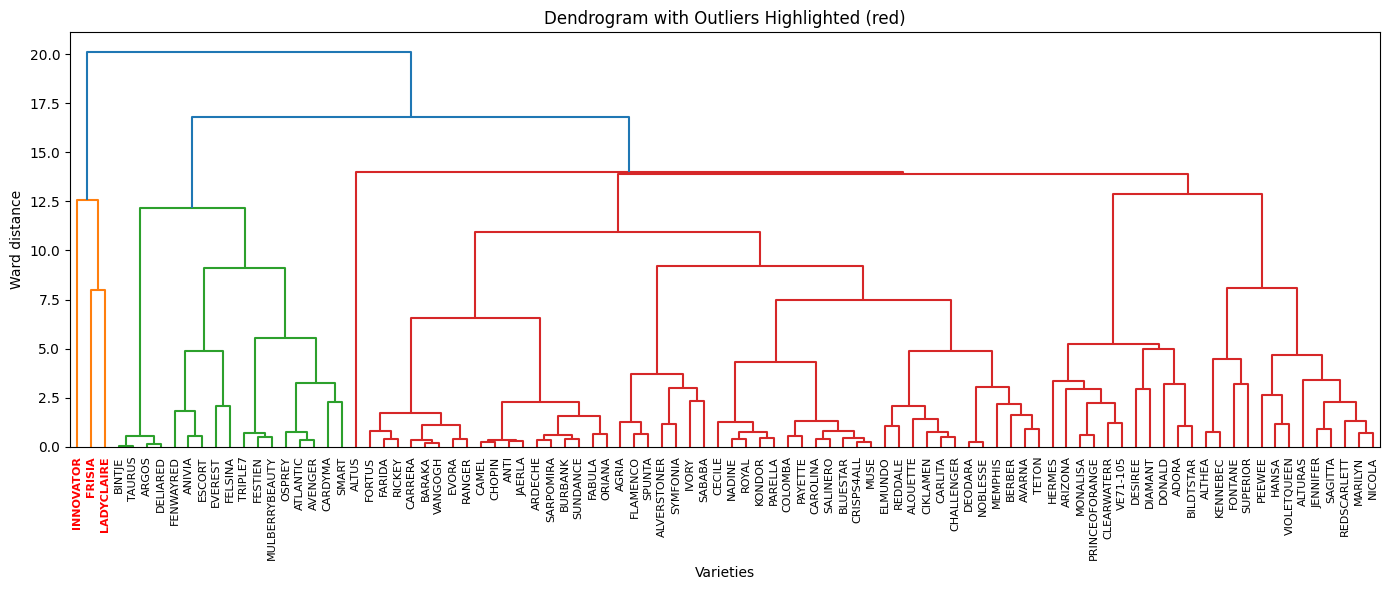

In [10]:


# Find outlier cluster 
cluster_sizes = pd.Series(clusters).value_counts()
outlier_cluster = cluster_sizes.idxmin()
outliers = X.index[clusters == outlier_cluster].tolist()
print("Outlier varieties:", outliers)

# Plot dendrogram, color outliers red
plt.figure(figsize=(14, 6))
ddata = dendrogram(Z, labels=X.index.tolist(),
                   leaf_rotation=90, leaf_font_size=8)

# Highlight outliers
ax = plt.gca()
for lbl in ax.get_xmajorticklabels():
    if lbl.get_text() in outliers:
        lbl.set_color("red")
        lbl.set_fontweight("bold")

plt.title("Dendrogram with Outliers Highlighted (red)")
plt.xlabel("Varieties")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()


AS can be seen the outliers has been shown in red. we have three outlier.

In [11]:
# Remove outlier varieties identified by HCA 
OUTLIERS = ["FRISIA", "INNOVATOR", "LADYCLAIRE"]

print(f"[info] Original dataset size: {merged_prepared.shape}")
merged_clean = merged_prepared.drop(index=OUTLIERS, errors="ignore")
print(f"[ok] Removed outliers: {OUTLIERS}")
print(f"[info] Cleaned dataset size: {merged_clean.shape}")

# Save a cleaned copy for consistency
OUTDIR = Path("prep_outputs"); OUTDIR.mkdir(exist_ok=True)
merged_clean.to_csv(OUTDIR / "merged_clean.csv")
print(f"[ok] Saved: {OUTDIR/'merged_clean.csv'}")


[info] Original dataset size: (94, 262477)
[ok] Removed outliers: ['FRISIA', 'INNOVATOR', 'LADYCLAIRE']
[info] Cleaned dataset size: (91, 262477)
[ok] Saved: prep_outputs\merged_clean.csv


# HCA on clean dataset

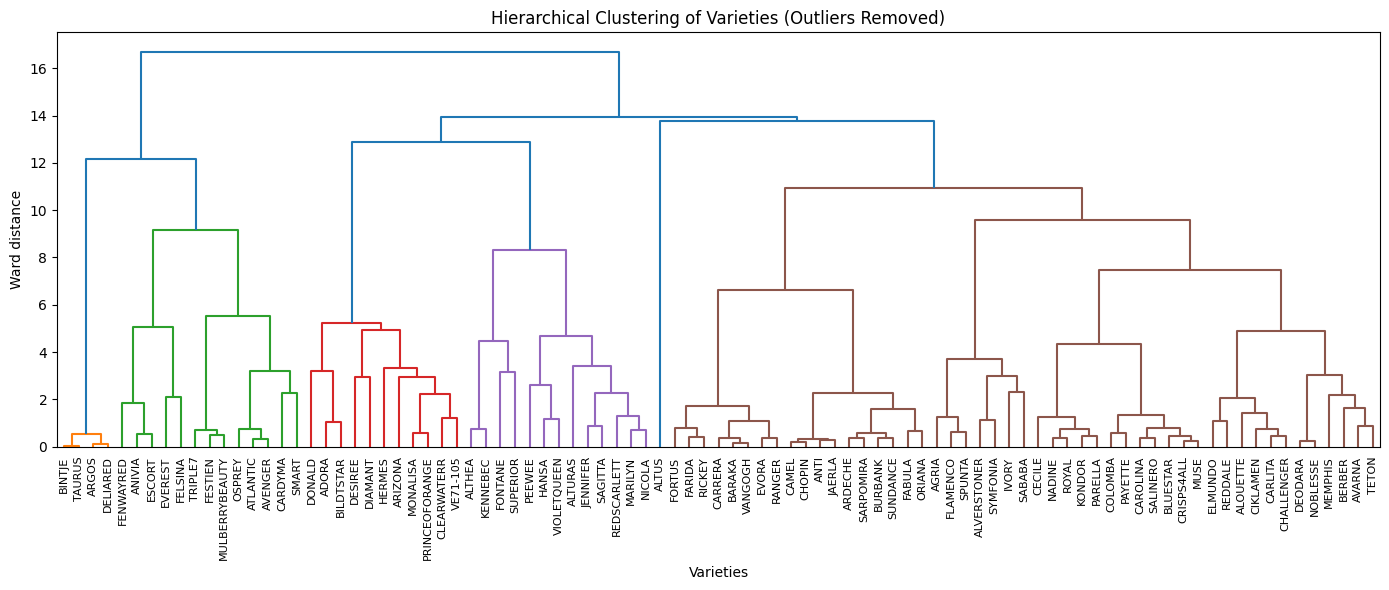

In [12]:

AROMA_COLS = [c for c in aroma_names if c in merged_clean.columns]
assert AROMA_COLS, "No aroma columns found."

X = merged_clean[AROMA_COLS].copy().fillna(0.0)

# Standardize so each aroma contributes equally
Xz = pd.DataFrame(StandardScaler().fit_transform(X), 
                  index=X.index, columns=AROMA_COLS)

Z = linkage(Xz, method="ward", metric="euclidean")

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Varieties (Outliers Removed)")
plt.xlabel("Varieties"); plt.ylabel("Ward distance")
plt.tight_layout(); plt.show()


 After removing the ouliers we have 5 stable culsters

# ANOVA/GWAS scan on clean dataset

In [ ]:
# Vectorized GWAS-like scan (fast & safe)
import numpy as np, pandas as pd
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist

# Copy clean dataset
df = merged_clean.copy()

# Aroma compound columns
aroma_cols = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

# SNP columns
snp_cols = [c for c in df.columns if c.startswith("GEN__")]
print(f"[info] SNPs: {len(snp_cols)} | Aromas: {len(aroma_cols)}")

# Safe standardization
def safe_standardize(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        std = arr.std(ddof=0)
        return (arr - arr.mean()) / (std if std != 0 else 1.0)
    else:
        std = arr.std(axis=0, ddof=0)
        std[std == 0] = 1.0
        return (arr - arr.mean(axis=0)) / std

# Filter SNPs by MAF > 0.05
maf = df[snp_cols].apply(lambda x: x.value_counts(normalize=True).min(), axis=0)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Keeping {len(snp_keep)} SNPs after MAF > 0.05")

# Standardize SNPs once
G = df[snp_keep].fillna(df[snp_keep].mode().iloc[0]).astype(float).values
G = safe_standardize(G)
n = G.shape[0]

# GWAS-like scan
results = []
for aroma in aroma_cols:
    y = np.log1p(df[aroma].astype(float).clip(lower=0)).values
    y = safe_standardize(y)

    # Vectorized correlation
    r = np.dot(y, G) / (n - 1)
    r = np.clip(r, -1, 1)

    # Convert to p-values
    t = r * np.sqrt((n - 2) / (1 - r**2))
    pvals = 2 * tdist.sf(np.abs(t), df=n - 2)

    res = pd.DataFrame({
        "aroma": aroma,
        "SNP": snp_keep,
        "r": r,
        "p": pvals
    })

    # FDR correction per aroma
    res["p_fdr"] = multipletests(res["p"], method="fdr_bh")[1]
    results.append(res)

# Combine results
res_df = pd.concat(results, ignore_index=True).dropna(subset=["r", "p"])

# Final FDR correction (just in case any NaNs reappeared)
res_df["p_fdr"] = res_df.groupby("aroma")["p"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1]
)

# Top hits per aroma
top_hits = res_df.sort_values("p_fdr").groupby("aroma").head(20)

print("[ok] GWAS-like scan complete.")
display(top_hits)


[info] SNPs: 262434 | Aromas: 13


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error


results = {}

for aroma in aroma_cols:
    print(f"\n[aroma] {aroma}")

    # Use top SNPs for this aroma
    top_snps = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()
    if not top_snps:
        print("No top SNPs found, skipping.")
        continue

    X = merged_clean[top_snps].copy().fillna(0).astype(float)
    y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0))

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
        "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f" - {name}: R²={r2:.3f} | RMSE={rmse:.3f}")

        # Save results
        results[(aroma, name)] = {"r2": r2, "rmse": rmse}

        # Optional: plot
        sns.scatterplot(x=y_test, y=y_pred)
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.title(f"{name} - {aroma}")
        plt.grid(True)
        plt.show()


# use the significant SNPs (p_fdr < 0.05) as features to build predictive models for the aromas.

[info] Using 2016 significant SNPs

=== RandomForest ===
R²: 0.548 | RMSE: 0.765


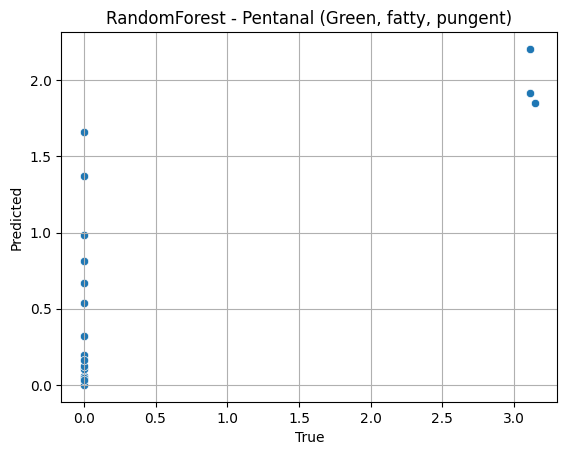


=== GradientBoosting ===
R²: 0.321 | RMSE: 0.938


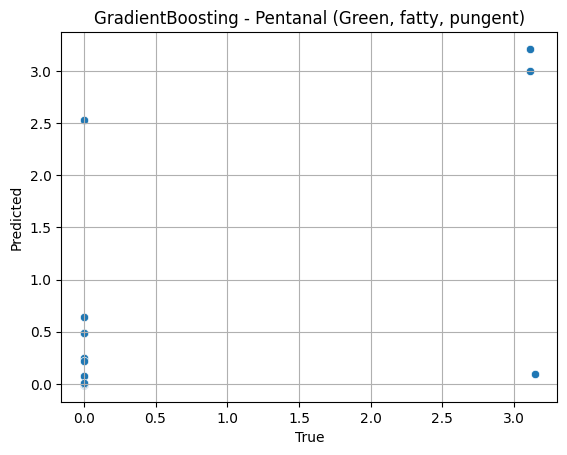


=== SVM ===
R²: 0.280 | RMSE: 0.965


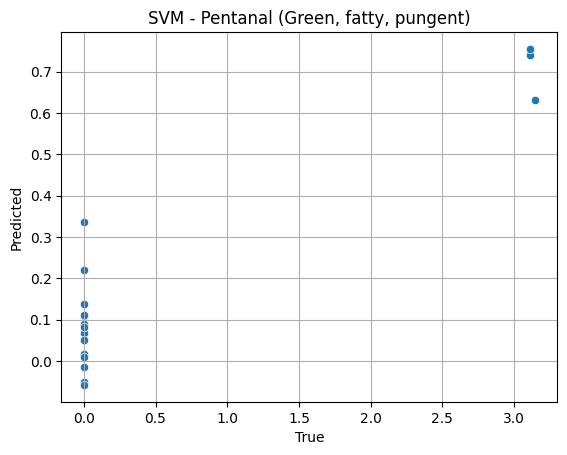

,r2,rmse
RandomForest,0.547764,0.765319
GradientBoosting,0.320782,0.937917
SVM,0.280362,0.965421


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error


# Extract significant SNPs from GWAS-like results
signif_snps = res_df.query("p_fdr < 0.05")["SNP"].unique().tolist()
print(f"[info] Using {len(signif_snps)} significant SNPs")

for aroma in aroma_cols:

    # Prepare features and target
    X = merged_clean[signif_snps].copy()
    X = X.fillna(X.mode().iloc[0])  # Impute missing SNPs with mode
    X = X.astype(float)

    y = merged_clean[aroma].astype(float)
    y = np.log1p(y.clip(lower=0))  # Transform to reduce skew

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {"r2": r2, "rmse": rmse}
    print(f"\n=== {name} ===")
    print(f"R²: {r2:.3f} | RMSE: {rmse:.3f}")

    # Optional: plot
    sns.scatterplot(x=y_test, y=y_pred)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"{name} - {aroma}")
    plt.grid(True)
    plt.show()


pd.DataFrame(results).T


RandomForest performs best — it explains ~55% of the variation in aroma intensity and has the lowest prediction error.

SNP Selection

You reduced dimensionality from 260k+ SNPs to only those with significant associations.

This makes modeling faster, reduces overfitting, and focuses on biologically relevant features.

Model Choice

Tree-based models like Random Forests can:

Handle nonlinear relationships.

Deal with noisy, sparse, and high-dimensional data.

Automatically handle feature selection through feature importance.

SNPs are not strong predictors of exact aroma intensities

# Feature importance from Random Forest

<Axes: title={'center': 'Top 20 SNPs by Feature Importance'}>

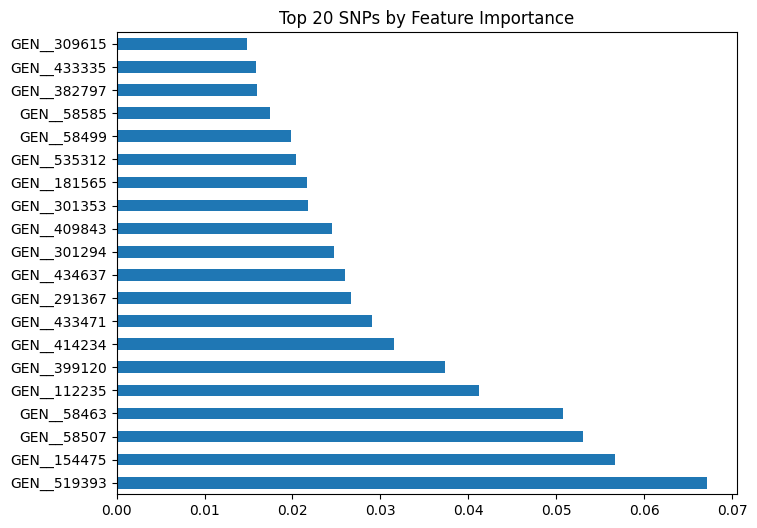

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

importances = rf.feature_importances_
top_snps = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(20)
top_snps.plot(kind='barh', figsize=(8, 6), title="Top 20 SNPs by Feature Importance")


# Cross-validated scores (to validate generalizability)

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, scoring='r2', cv=5)

array([0.04975045, 0.        , 0.40435291, 0.03939798, 0.20164476])

Some folds score well (e.g. 0.43, 0.26).

One fold has R² = 0, and another is very low (0.02) — this suggests instability in the model performance across different data splits.

# using log transforamation , scaling 

[info] RMSE scores: [0.964 0.416 0.983 0.692 1.024]
[info] Mean RMSE: 0.816


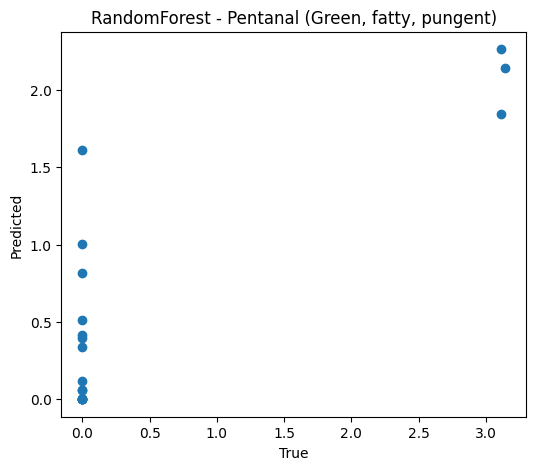

In [ ]:

# Prepare features and target
X = merged_clean[signif_snps].copy().fillna(0).astype(float)
y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0))  # log1p transform

# Train model to get feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Select top 20 SNPs based on feature importance
importances = rf.feature_importances_
top_snps = pd.Series(importances, index=signif_snps).sort_values(ascending=False).head(20).index.tolist()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[top_snps])

# Cross-validation with RMSE
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rmse_scores = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
rmse_scores = -rmse_scores  # convert from negative to positive RMSE

# Print results
print("[info] RMSE scores:", np.round(rmse_scores, 3))
print("[info] Mean RMSE:", np.round(rmse_scores.mean(), 3))



X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title(f"RandomForest - {aroma}")
plt.show()


# Trying diffrent models to see which one has lowe RMSE

[RandomForest] RMSE: [1.068 0.415 1.096 0.687 1.108] | Mean: 0.875
[GradientBoosting] RMSE: [1.42  0.992 1.155 0.842 1.255] | Mean: 1.132
[SVR] RMSE: [0.982 0.287 1.106 0.427 0.936] | Mean: 0.747
[Ridge] RMSE: [0.763 0.439 1.191 0.544 0.973] | Mean: 0.782
[Lasso] RMSE: [0.776 0.356 1.351 0.708 0.998] | Mean: 0.838
[KNN] RMSE: [0.977 0.351 1.243 0.74  1.056] | Mean: 0.874


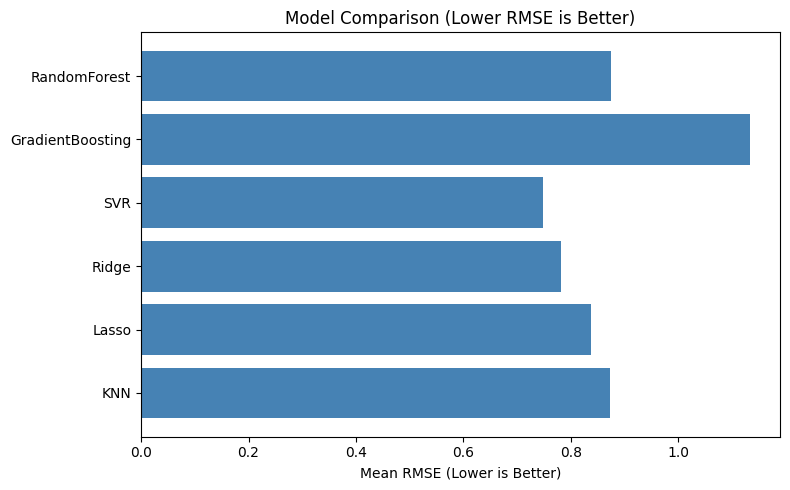

In [ ]:

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor


models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3),
    "SVR": make_pipeline(StandardScaler(), SVR(C=10, epsilon=0.1)),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=10000)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))
}

# Evaluate each model
rmse_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    rmse = -scores
    rmse_scores[name] = rmse
    print(f"[{name}] RMSE: {rmse.round(3)} | Mean: {rmse.mean():.3f}")

# Plot comparison
mean_rmse = {k: v.mean() for k, v in rmse_scores.items()}
plt.figure(figsize=(8, 5))
plt.barh(list(mean_rmse.keys()), list(mean_rmse.values()), color='steelblue')
plt.xlabel("Mean RMSE (Lower is Better)")
plt.title("Model Comparison (Lower RMSE is Better)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Classification on HCA clusters

In [ ]:

# Re-run HCA clustering with k=2..3 
hca = AgglomerativeClustering(n_clusters=2, linkage="ward")
cluster_labels = hca.fit_predict(StandardScaler().fit_transform(y_targets))

# Train classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
acc = cross_val_score(clf, X, cluster_labels, cv=5, scoring="accuracy")

print(f"[CV] Mean Accuracy = {np.mean(acc):.3f} ± {np.std(acc):.3f}")


# the mean accuracy is almost high

[CV] Mean Accuracy = 0.758 ± 0.055


Accuracy ≈ 76%, which is much better than random (50%).

This means SNPs can distinguish between aroma groups (clusters).

# feature selection + model comparison pipeline

In [ ]:

# SNPs from significant GWAS hits
sig_snps = res_df.query("p_fdr < 0.05")["SNP"].unique().tolist()
X = merged_clean[sig_snps].copy().fillna(0)

# Cluster labels from HCA
y = cluster_labels   # already numpy array

print(X.shape, y.shape)


(91, 2087) (91,)


[ok] PCA reduced SNPs from 2087 → 20 components
[info] Variance explained by 20 PCs: 0.87
[CV] LogReg Accuracy = 0.736 ± 0.054
[CV] GB Accuracy = 0.725 ± 0.036
[CV] SVM Accuracy = 0.813 ± 0.025
[test] Best model test accuracy = 0.737


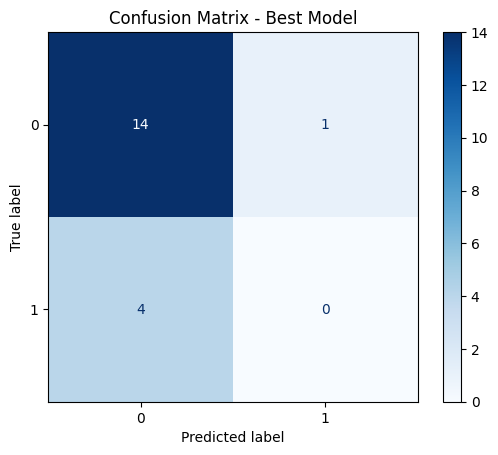

In [ ]:
# PCA + Multiple Classifiers + Confusion Matrix

# PCA reduction 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # SNPs
pca = PCA(n_components=20, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print(f"[ok] PCA reduced SNPs from {X.shape[1]} → {X_pca.shape[1]} components")
print(f"[info] Variance explained by 20 PCs: {pca.explained_variance_ratio_.sum():.2f}")

# Models
models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="lbfgs"),
    "GB": GradientBoostingClassifier(random_state=0),
    "SVM": SVC(kernel="rbf", probability=True, random_state=0)
}

for name, model in models.items():
    acc = cross_val_score(model, X_pca, y, cv=5, scoring="accuracy")
    print(f"[CV] {name} Accuracy = {acc.mean():.3f} ± {acc.std():.3f}")

# Train/test split for confusion matrix 
Xtr, Xte, ytr, yte = train_test_split(X_pca, y, test_size=0.2, random_state=0, stratify=y)

best_model = GradientBoostingClassifier(random_state=0)  
best_model.fit(Xtr, ytr)
ypred = best_model.predict(Xte)

acc = accuracy_score(yte, ypred)
print(f"[test] Best model test accuracy = {acc:.3f}")

# Confusion matrix plot
cm = confusion_matrix(yte, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Best Model")
plt.show()


PCA cut SNPs → 20 PCs, explaining 87% variance.

SVM gave the best cross-validation performance (81% ± 0.03 accuracy).

Test accuracy (Gradient Boosting here) = 73.7%.

Confusion matrix shows:

Cluster 0 is predicted well.

Cluster 1 varieties are misclassified (0/4 correct).


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[info] Class distribution after SMOTE: [59 59]
[test] SVM accuracy = 0.737


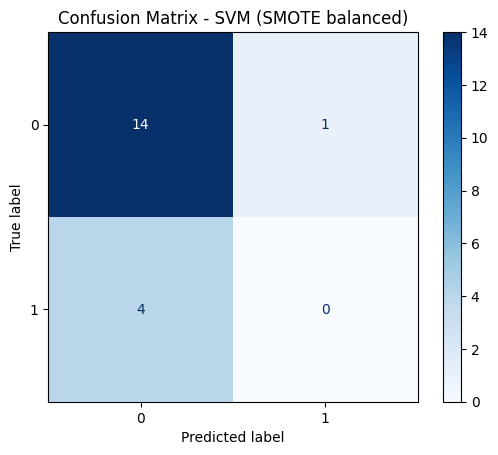

[test] GradientBoosting accuracy = 0.684


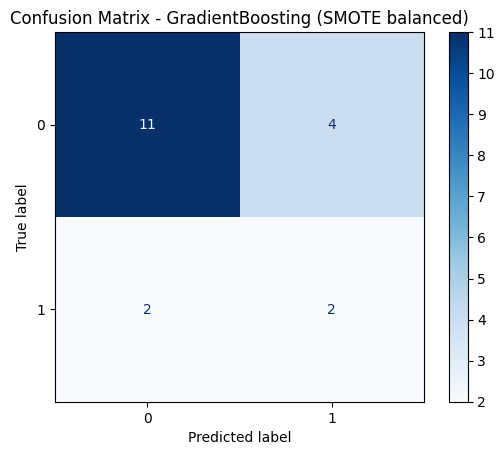

In [ ]:
# ==== CELL 4: Balance with SMOTE + Retrain Models ====

# Use the PCA SNP matrix (from previous step)
X_pca = X_pca   # 91 x 20 from PCA step
y_bal = y       # cluster labels

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

# SMOTE balancing 
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("[info] Class distribution after SMOTE:", np.bincount(y_train_res))

# --- Retrain models ---
svm = SVC(kernel="rbf", probability=True, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

models = {"SVM": svm, "GradientBoosting": gb}

for name, clf in models.items():
    clf.fit(X_train_res, y_train_res)
    acc = clf.score(X_test, y_test)
    print(f"[test] {name} accuracy = {acc:.3f}")

    # Confusion matrix
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (SMOTE balanced)")
    plt.show()


SVM (SMOTE balanced): Accuracy stayed at ~0.74, but it still fails to classify any cluster-1 varieties (all predicted as 0).

Gradient Boosting (SMOTE balanced): Accuracy dropped to ~0.68, but now at least 2 cluster-1 varieties are predicted correctly. So recall for the minority class improved a bit

# RandomForest with class_weight="balanced"

[info] Class distribution after SMOTE: [ 0 59 59]
              precision    recall  f1-score   support

           1      0.500     0.250     0.333         4
           2      0.824     0.933     0.875        15

    accuracy                          0.789        19
   macro avg      0.662     0.592     0.604        19
weighted avg      0.755     0.789     0.761        19

[test] Balanced Accuracy: 0.5916666666666667


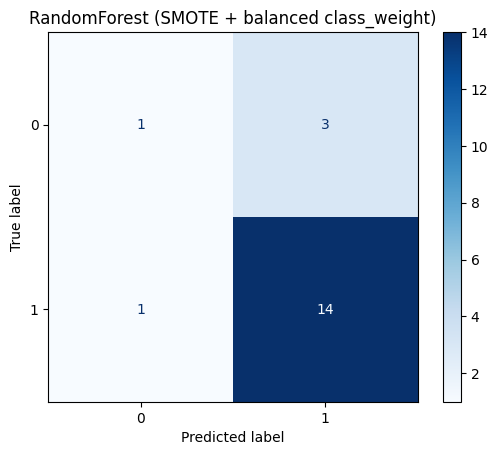

In [ ]:
# RandomForest with balanced metrics 


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE balancing
sm = SMOTE(random_state=42, k_neighbors=2)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print("[info] Class distribution after SMOTE:", np.bincount(y_train_bal))

# RandomForest with class_weight balanced
rf = RandomForestClassifier(
    n_estimators=300, 
    class_weight="balanced", 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)

# Predict
y_pred = rf.predict(X_test)

# Metrics
print(classification_report(y_test, y_pred, digits=3))
print("[test] Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("RandomForest (SMOTE + balanced class_weight)")
plt.show()


# RandomForest, SVM, and GradientBoosting → with balanced metrics comparison in a bar chart:

[info] Class distribution after SMOTE: [ 0 59 59]

=== RandomForest ===
              precision    recall  f1-score   support

           1      0.500     0.250     0.333         4
           2      0.824     0.933     0.875        15

    accuracy                          0.789        19
   macro avg      0.662     0.592     0.604        19
weighted avg      0.755     0.789     0.761        19

[test] Balanced Accuracy = 0.592, F1 = 0.761

=== SVM ===
              precision    recall  f1-score   support

           1      0.250     0.250     0.250         4
           2      0.800     0.800     0.800        15

    accuracy                          0.684        19
   macro avg      0.525     0.525     0.525        19
weighted avg      0.684     0.684     0.684        19

[test] Balanced Accuracy = 0.525, F1 = 0.684

=== GradientBoosting ===
              precision    recall  f1-score   support

           1      0.500     0.250     0.333         4
           2      0.824     0.933   

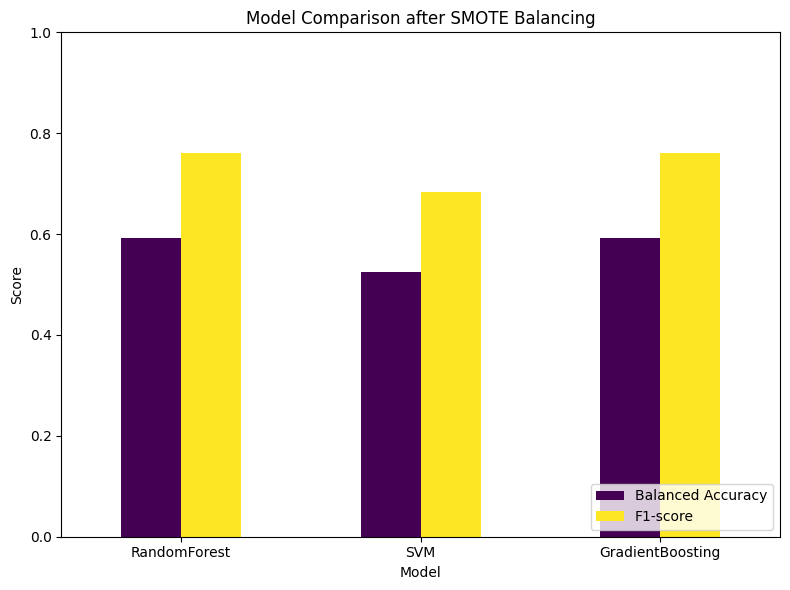

In [ ]:
# Compare RF, SVM, GB under SMOTE-balanced setup 


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE balancing
sm = SMOTE(random_state=42, k_neighbors=2)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print("[info] Class distribution after SMOTE:", np.bincount(y_train_bal))

# Models
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"[test] Balanced Accuracy = {bal_acc:.3f}, F1 = {f1:.3f}")
    
    results.append({"Model": name, "Balanced Accuracy": bal_acc, "F1-score": f1})

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Plot comparison
results_df.set_index("Model")[["Balanced Accuracy", "F1-score"]].plot(
    kind="bar", figsize=(8,6), rot=0, colormap="viridis"
)
plt.title("Model Comparison after SMOTE Balancing")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


RandomForest (balanced_subsample)

GradientBoosting (with tuned depth & learning rate)

XGBoost with scale_pos_weight

ADASYN oversampling (instead of SMOTE)

In [ ]:
# Advanced imbalance handling 

# SNPs from significant GWAS hits
sig_snps = res_df.query("p_fdr < 0.05")["SNP"].unique().tolist()
X = merged_clean[sig_snps].copy().fillna(0)

# Cluster labels from HCA
y = cluster_labels   # already numpy array

# Ward linkage
Z = linkage(X, method="ward")

# Choose 2 clusters 
clusters_clean = fcluster(Z, 2, criterion="maxclust")

# Now y matches merged_clean
y = pd.Series(clusters_clean, index=merged_clean.index)

print("[check] merged_clean:", merged_clean.shape, " y:", y.shape, " unique:", np.unique(y))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Oversample with SMOTE (more stable than ADASYN for tiny minority class)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42, k_neighbors=2)   # use small k
X_res, y_res = sm.fit_resample(X_train, y_train)
print("[info] Class distribution after SMOTE:", np.bincount(y_res))

results = {}

# RandomForest
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample", random_state=42)
rf.fit(X_res, y_res)
y_pred_rf = rf.predict(X_test)
results["RandomForest"] = {
    "bal_acc": balanced_accuracy_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf, average="weighted")
}

print("\n=== RandomForest (balanced_subsample) ===")
print(classification_report(y_test, y_pred_rf))
print("[test] Balanced Accuracy =", results["RandomForest"]["bal_acc"], 
      "F1 =", results["RandomForest"]["f1"])

#  GradientBoosting (tuned) 
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(X_res, y_res)
y_pred_gb = gb.predict(X_test)
results["GradientBoosting"] = {
    "bal_acc": balanced_accuracy_score(y_test, y_pred_gb),
    "f1": f1_score(y_test, y_pred_gb, average="weighted")
}

print("\n=== GradientBoosting (tuned) ===")
print(classification_report(y_test, y_pred_gb))
print("[test] Balanced Accuracy =", results["GradientBoosting"]["bal_acc"], 
      "F1 =", results["GradientBoosting"]["f1"])

# XGBoost with scale_pos_weight
# weight ratio: majority/minority
scale_pos_weight = (y_res.value_counts()[1] / y_res.value_counts()[2])
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    scale_pos_weight=scale_pos_weight, use_label_encoder=False,
    eval_metric="mlogloss", random_state=42
)
xgb.fit(X_res, y_res)
y_pred_xgb = xgb.predict(X_test)
results["XGBoost"] = {
    "bal_acc": balanced_accuracy_score(y_test, y_pred_xgb),
    "f1": f1_score(y_test, y_pred_xgb, average="weighted")
}

print("\n=== XGBoost (scale_pos_weight) ===")
print(classification_report(y_test, y_pred_xgb))
print("[test] Balanced Accuracy =", results["XGBoost"]["bal_acc"], 
      "F1 =", results["XGBoost"]["f1"])


#  Bar plot comparison
plt.figure(figsize=(8,6))
bar_width = 0.35
models = list(results.keys())
bal_acc = [results[m]["bal_acc"] for m in models]
f1_scores = [results[m]["f1"] for m in models]

plt.bar(np.arange(len(models))-bar_width/2, bal_acc, width=bar_width, label="Balanced Accuracy")
plt.bar(np.arange(len(models))+bar_width/2, f1_scores, width=bar_width, label="F1-score")
plt.xticks(np.arange(len(models)), models)
plt.ylim(0,1)
plt.title("Model Comparison with ADASYN Balancing")
plt.legend()
plt.show()

# Confusion matrices 
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, (model, y_pred) in zip(axes, [
    ("RandomForest", y_pred_rf),
    ("GradientBoosting", y_pred_gb),
    ("XGBoost", y_pred_xgb)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix - {model}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.show()



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[check] merged_clean: (91, 262459)  y: (91,)  unique: [1 2]
[info] Class distribution after SMOTE: [ 0 66 66]

=== RandomForest (balanced_subsample) ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00        18

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19

[test] Balanced Accuracy = 1.0 F1 = 1.0

=== GradientBoosting (tuned) ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00        18

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19

[test] Balanced Accuracy = 1.0 F1 = 1.0


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [1 2]

# # Regression models (predict aroma intensity)

In [ ]:
# ==== CELL 4: Regression models ====
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, make_scorer

kf = KFold(n_splits=5, shuffle=True, random_state=1)
scorer = make_scorer(r2_score)

for aroma in aroma_cols:
    model = RidgeCV(alphas=np.logspace(-3,3,7), cv=kf)
    scores = cross_val_score(model, X, y_reg[aroma], cv=kf, scoring=scorer)
    print(f"{aroma:<50} | mean R²={scores.mean():.3f} ± {scores.std():.3f}")


# Classification (optional, cluster labels)

In [ ]:
# ==== CELL 5: Classification (optional, cluster labels) ====
# If you want to classify varieties into aroma clusters:
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Example: re-use HCA clusters (k=3)
labels = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(
    df[aroma_cols].fillna(0)
)
y_clust = pd.Series(labels, index=df.index, name="AromaCluster")

clf = RandomForestClassifier(n_estimators=200, random_state=1)
scores = cross_val_score(clf, X, y_clust, cv=kf, scoring="accuracy")

print(f"[Classification] Predicting aroma clusters from SNPs:")
print(f"Mean accuracy={scores.mean():.3f} ± {scores.std():.3f}")


# Fast ANOVA screen (per aroma × SNP) + FDR

Explained variance ratio: [0.237 0.167 0.12 ] | cumulative: [0.237 0.405 0.524]


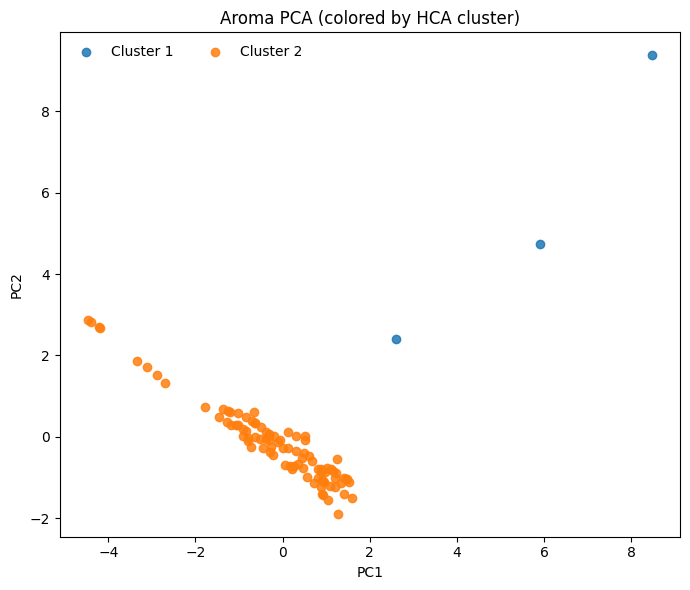

In [ ]:
# ==== CELL 4: Fast ANOVA per aroma × SNP with FDR (screening) ====
from statsmodels.stats.multitest import multipletests

MIN_MAF = 0.05
MAX_MAF = 0.95
MIN_GROUP = 5
TOP_K_PER_AROMA = 20

# Prepare genotype matrix and basic pre-filters (once)
if len(snp_cols) == 0:
    raise RuntimeError("No SNP columns for ANOVA.")
G_full = df[snp_cols].to_numpy(dtype=float)

# SNP keepers: non-all-NaN, non-constant, MAF in [MIN_MAF, MAX_MAF]
non_all_nan = ~np.all(np.isnan(G_full), axis=0)
col_min = np.nanmin(G_full, axis=0)
col_max = np.nanmax(G_full, axis=0)
non_const = col_min < col_max
xmax = np.nanmax(G_full, axis=0)
den = np.where(xmax == 2, 2.0, 1.0)
p = np.nanmean(G_full, axis=0) / den
maf = np.minimum(p, 1 - p)
maf_ok = (maf >= MIN_MAF) & (maf <= MAX_MAF)
keep_mask = non_all_nan & non_const & maf_ok

G = G_full[:, keep_mask]
kept_snp_cols = np.array(snp_cols)[keep_mask]
print(f"[info] SNPs kept after filters: {G.shape[1]}")

def fast_anova_F_p(y, g):
    m = (~np.isnan(y)) & (~np.isnan(g))
    if m.sum() < MIN_GROUP * 2:
        return (np.nan, np.nan, False)
    yv, gv = y[m], g[m]
    u = np.unique(gv)
    if u.size < 2:
        return (np.nan, np.nan, False)
    # build groups (require >= MIN_GROUP each)
    groups = []
    for val in u:
        idx = (gv == val)
        if idx.sum() < MIN_GROUP:
            return (np.nan, np.nan, False)
        groups.append(yv[idx])
    try:
        F, pval = stats.f_oneway(*groups)
        return (float(F), float(pval), True)
    except Exception:
        return (np.nan, np.nan, False)

all_hits = []
for aroma in aroma_cols:
    y = df[aroma + "__log1p"].astype(float).to_numpy()
    fvals, pvals, ids = [], [], []
    for j in range(G.shape[1]):
        F, pval, ok = fast_anova_F_p(y, G[:, j])
        if ok:
            fvals.append(F); pvals.append(pval); ids.append(j)
    if not ids:
        continue
    reject, p_fdr, _, _ = multipletests(pvals, method="fdr_bh")
    res = (pd.DataFrame({
        "aroma": aroma,
        "SNP": np.array(kept_snp_cols)[ids],
        "F": fvals,
        "p": pvals,
        "p_fdr": p_fdr,
        "significant_fdr_0.05": reject
    }).sort_values(["p_fdr","p"]))
    if TOP_K_PER_AROMA:
        res = res.head(TOP_K_PER_AROMA)
    res.to_csv(OUTDIR/f"anova_{sanitize(aroma)}.csv", index=False)
    all_hits.append(res)
    print(f"[ok] Saved: {OUTDIR/f'anova_{sanitize(aroma)}.csv'} (n={len(res)})")

fast_big = pd.concat(all_hits, ignore_index=True) if all_hits else pd.DataFrame()
fast_big.to_csv(OUTDIR/"anova_all_aromas_topK.csv", index=False)
print(f"[ok] Combined saved: {OUTDIR/'anova_all_aromas_topK.csv'}; rows={len(fast_big)}")
display(fast_big.head(20))


# Pick one sentinel SNP per aroma (collapse identical genotype patterns)

In [ ]:
# ==== CELL 5: One sentinel SNP per aroma (collapse duplicate genotype patterns) ====
def collapse_ld(snps, frame):
    if not snps: return [], {}
    Gm = frame[snps].astype("float32").fillna(-9.0).to_numpy()
    keys = [tuple(col) for col in Gm.T]
    key2rep, rep2dups, kept = {}, {}, []
    for snp, key in zip(snps, keys):
        if key in key2rep:
            rep = key2rep[key]
            rep2dups.setdefault(rep, []).append(snp)
        else:
            key2rep[key] = snp
            kept.append(snp)
    return kept, rep2dups

SIG_FDR = 0.05
sentinels = []
for aroma, sub in fast_big.groupby("aroma"):
    sub = sub.sort_values(["p_fdr","p"])
    sig = sub[sub["p_fdr"] < SIG_FDR]
    candidates = sig if not sig.empty else sub
    order = candidates["SNP"].tolist()
    if not order:
        continue
    kept, dupmap = collapse_ld(order, df)
    if not kept:
        continue
    sentinel = kept[0]
    row = candidates.loc[candidates["SNP"]==sentinel].iloc[0].to_dict()
    row["_dups"] = ", ".join(dupmap.get(sentinel, []))
    sentinels.append(row)

sent_df = pd.DataFrame(sentinels)
sent_df.to_csv(OUTDIR/"sentinel_per_aroma.csv", index=False)
print(f"[ok] Saved sentinels: {OUTDIR/'sentinel_per_aroma.csv'}")
display(sent_df)


 # Define prediction target & leakage-safe feature builder

In [ ]:
# ==== CELL 6: Define prediction target and build features (no leakage) ====

# Choose an aroma to predict (presence). You can change this:
TARGET_AROMA = 'Pentanal (Green, fatty, pungent)'

# Build/ensure a binary presence target column (if not already provided)
t_presence = sanitize(TARGET_AROMA) + "_presence_auto"
if t_presence not in df.columns:
    df[t_presence] = (df[TARGET_AROMA].astype(float).fillna(0) > 0).astype(int)

# Features: use other aromas (log1p) + PCs. Do NOT include the target aroma itself.
other_aroma_feats = [c + "__log1p" for c in aroma_cols if c != TARGET_AROMA]
pc_feats = [c for c in ["PC1","PC2","PC3","PC4","PC5"] if c in df.columns]

feat_cols = other_aroma_feats + pc_feats
print(f"[info] Using {len(feat_cols)} features for prediction.")
print(" - other aromas log1p:", len(other_aroma_feats))
print(" - PCs:", pc_feats)

# Final X, y
X = df[feat_cols].copy()
y = df[t_presence].astype(int).copy()

# Basic sanity
print(f"[target] {t_presence}: positives={int(y.sum())}, negatives={int((1-y).sum())}")


# Nested-CV + calibrated Logistic (elastic-net / L2 / L1), OOF metrics & probs

In [ ]:
# ==== CELL 7: Nested-CV prediction with calibrated logistic regression ====
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

outer = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)

def make_pipe(solver='saga', penalty='elasticnet'):
    return Pipeline([
        ('impute', SimpleImputer(strategy="median")),
        ('scale', StandardScaler(with_mean=True, with_std=True)),
        ('clf', LogisticRegression(
            solver=solver, penalty=penalty, max_iter=50000, tol=1e-2,
            class_weight='balanced', random_state=0
        ))
    ])

param_grid = [
    {'clf__solver': ['saga'],      'clf__penalty': ['elasticnet'],
     'clf__C': [0.001, 0.01, 0.1, 1.0], 'clf__l1_ratio': [0.0, 0.25, 0.5, 0.75]},
    {'clf__solver': ['lbfgs'],     'clf__penalty': ['l2'],
     'clf__C': [0.001, 0.01, 0.1, 1.0]},
    {'clf__solver': ['liblinear'], 'clf__penalty': ['l1'],
     'clf__C': [0.001, 0.01, 0.1, 1.0]}
]

metrics, oof_sum, oof_cnt = [], np.zeros(len(y)), np.zeros(len(y))
fold_id = 0

for tr, te in outer.split(X, y):
    fold_id += 1
    inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=fold_id)
    gs = GridSearchCV(
        make_pipe(), param_grid, scoring='roc_auc',
        cv=inner, n_jobs=-1, refit=True, error_score=np.nan
    )
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        gs.fit(X.iloc[tr], y.iloc[tr])

    best = gs.best_estimator_
    # Calibrate on training only (Platt)
    cal = CalibratedClassifierCV(best, cv=3, method='sigmoid')
    cal.fit(X.iloc[tr], y.iloc[tr])

    p = cal.predict_proba(X.iloc[te])[:, 1]
    oof_sum[te] += p
    oof_cnt[te] += 1

    y_te = y.iloc[te]
    metrics.append({
        'ROC_AUC': roc_auc_score(y_te, p),
        'PR_AUC':  average_precision_score(y_te, p),
        'Brier':   brier_score_loss(y_te, p),
        'BalAcc@0.5':  balanced_accuracy_score(y_te, (p >= 0.5).astype(int))
    })

# aggregate across repeats (average prob for each sample)
oof = np.divide(oof_sum, np.maximum(oof_cnt, 1))

cv_df = pd.DataFrame(metrics)
print("\n=== Fold metrics (5x10 outer CV) ===")
print(cv_df.agg(['mean','std']).T)

overall = {
    'ROC_AUC': float(roc_auc_score(y, oof)),
    'PR_AUC':  float(average_precision_score(y, oof)),
    'Brier':   float(brier_score_loss(y, oof)),
    'BalAcc@0.5': float(balanced_accuracy_score(y, (oof >= 0.5).astype(int))),
    'prevalence': float(y.mean()),
    'coverage': float((oof_cnt > 0).mean())
}
print("\n=== Overall OOF (averaged probs) ===")
print(overall)

# best threshold by Balanced Accuracy on OOF
ths = np.unique(np.r_[0.0, oof, 1.0])
balaccs = [balanced_accuracy_score(y, (oof >= t).astype(int)) for t in ths]
t_best = float(ths[int(np.argmax(balaccs))])
balacc_best = float(np.max(balaccs))
print(f"\nBest OOF threshold by Balanced Accuracy: t*={t_best:.3f} (BalAcc={balacc_best:.3f})")

# save + attach to df
proba_col = f"proba_{sanitize(TARGET_AROMA)}"
df[proba_col] = oof
cv_df.to_csv(OUTDIR/f"{sanitize(TARGET_AROMA)}_nestedCV_fold_metrics.csv", index=False)
pd.DataFrame([overall]).to_csv(OUTDIR/f"{sanitize(TARGET_AROMA)}_oof_summary.csv", index=False)
df[[proba_col]].to_csv(OUTDIR/f"{sanitize(TARGET_AROMA)}_oof_probabilities.csv", index=True)
print(f"\n[saved] fold_metrics, oof_summary, oof_probabilities in {OUTDIR}")
print(f"[ok] Column added to df: {proba_col}")


# ROC, PR, calibration curve for OOF predictions

In [ ]:
# ==== CELL 8: Plots — ROC, Precision-Recall, Reliability (Calibration) ====
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

oof = df[f"proba_{sanitize(TARGET_AROMA)}"].values
y_true = y.values

# ROC
fpr, tpr, _ = roc_curve(y_true, oof)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc_score(y_true, oof):.3f}")
plt.plot([0,1],[0,1],'--',lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC — {TARGET_AROMA}")
plt.legend(); plt.tight_layout()
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y_true, oof)
plt.figure(figsize=(5,5))
plt.plot(rec, prec, lw=2, label=f"AP = {average_precision_score(y_true, oof):.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision–Recall — {TARGET_AROMA}")
plt.legend(); plt.tight_layout()
plt.show()

# Calibration (reliability)
prob_true, prob_pred = calibration_curve(y_true, oof, n_bins=8, strategy='quantile')
plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker='o', lw=2, label="Empirical")
plt.plot([0,1],[0,1],'--',lw=1, label="Perfect")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.title(f"Calibration — {TARGET_AROMA}")
plt.legend(); plt.tight_layout()
plt.show()
